In [ ]:
# ============================================
# CELLULE 1 - INSTALLATION & IMPORTS
# ============================================

# Installer les librairies nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet xgboost -q

# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statsmodels pour time series
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
from prophet import Prophet

# XGBoost
import xgboost as xgb

# Métriques
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("✅ Toutes les librairies sont importées")

✅ Toutes les librairies sont importées


In [ ]:
# ============================================
# CELLULE 2 - UPLOAD DES FICHIERS CSV
# ============================================

from google.colab import files
import io

print("="*60)
print("UPLOAD DES FICHIERS CSV")
print("="*60)
print("""
📤 Veuillez uploader les fichiers suivants :
   1. Fact_Vente.csv
   2. Dim_Date.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)
""")

# Upload des fichiers
uploaded = files.upload()

print(f"\n✅ {len(uploaded)} fichiers uploadés avec succès !")

# Charger les fichiers dans des dataframes
dfs = {}
for nom_fichier in uploaded.keys():
    nom_base = nom_fichier.replace('.csv', '').replace('.CSV', '')
    dfs[nom_base] = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"   ✅ {nom_base} : {dfs[nom_base].shape[0]} lignes")

# Assigner aux variables
df_vente = dfs.get('Fact_Vente')
df_date = dfs.get('Dim_Date')

print("\n✅ Tous les fichiers sont chargés !")

UPLOAD DES FICHIERS CSV

📤 Veuillez uploader les fichiers suivants :
   1. Fact_Vente.csv
   2. Dim_Date.csv

👉 Conseil : Sélectionnez les fichiers en même temps (Ctrl+clic)



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv

✅ 10 fichiers uploadés avec succès !
   ✅ Dim_Canal_Distribution : 4 lignes
   ✅ Dim_Client : 446 lignes
   ✅ Dim_Commandes : 442 lignes
   ✅ Dim_Date : 1461 lignes
   ✅ Dim_Fournisseur : 67 lignes
   ✅ Dim_Matiere_Premiere : 62 lignes
   ✅ Dim_Produits : 134 lignes
   ✅ Dim_Reclamations : 100 lignes
   ✅ Fact_Achat : 140 lignes
   ✅ Fact_Vente : 1386 lignes

✅ Tous les fichiers sont chargés !


CRÉATION DU CA MENSUEL
Colonnes disponibles dans Fact_Vente : ['vente_key', 'date_key', 'client_key', 'canal_key', 'produit_key', 'commande_key', 'reclamation_key', 'quantite', 'prix_unitaire_ht', 'montant_ht']
✅ Jointure avec Dim_Date effectuée

📊 CA mensuel calculé : 25 mois
  mois_annee  montant_ht
0    2023-12     18079.0
1    2024-02        75.0
2    2024-03       187.0
3    2024-04      1830.4
4    2024-05      2396.0
   mois_annee  montant_ht
20    2025-09     15588.7
21    2025-10      4010.5
22    2025-11      8113.1
23    2025-12     30485.6
24    2026-01         8.0


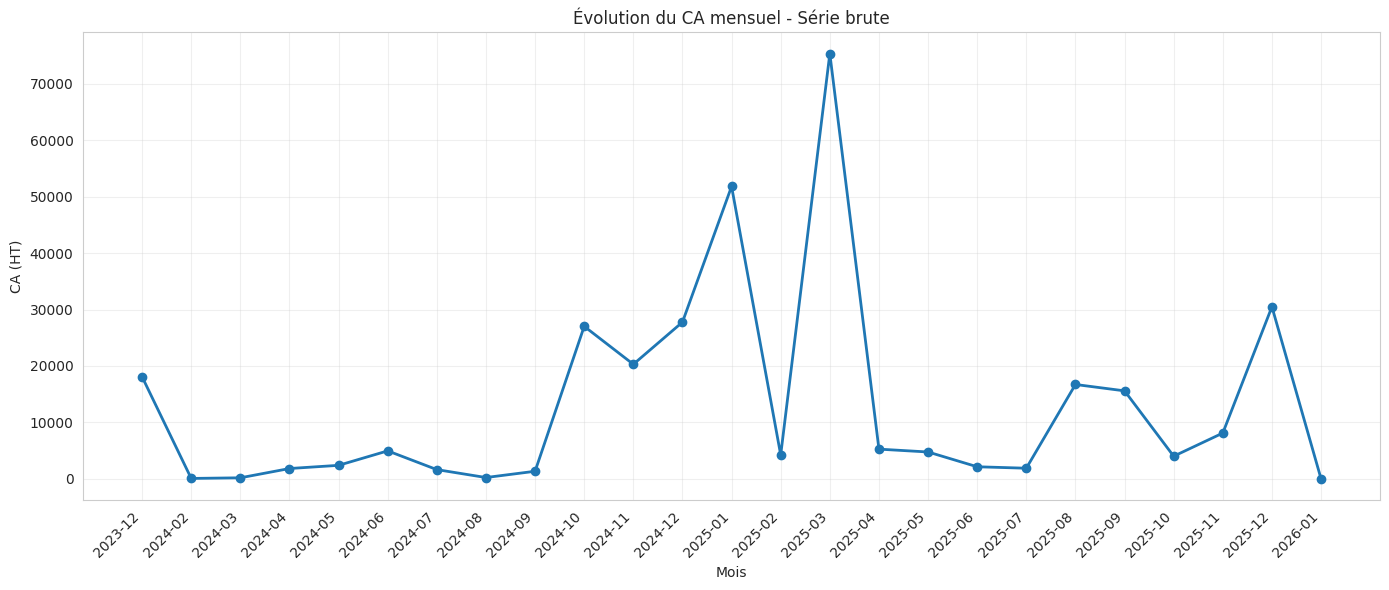

In [ ]:
# ============================================
# CELLULE 3 - CRÉATION DE LA SÉRIE TEMPORELLE
# ============================================

print("="*60)
print("CRÉATION DU CA MENSUEL")
print("="*60)

# Nettoyer les montants
def clean_float(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, str):
        try:
            return float(x.replace(',', '.'))
        except:
            return 0.0
    try:
        return float(x)
    except:
        return 0.0

if 'montant_ht' in df_vente.columns:
    df_vente['montant_ht'] = df_vente['montant_ht'].apply(clean_float)
    df_vente['revenue'] = df_vente['revenue'].apply(clean_float)

# Vérifier la colonne de date dans df_vente
print("Colonnes disponibles dans Fact_Vente :", df_vente.columns[:10].tolist())

# Si date_key est présent, faire la jointure avec Dim_Date
if 'date_key' in df_vente.columns and 'date_key' in df_date.columns:
    df_vente = df_vente.merge(df_date[['date_key', 'date_complete']], on='date_key', how='left')
    print("✅ Jointure avec Dim_Date effectuée")
elif 'date_complete' in df_vente.columns:
    df_vente['date_complete'] = pd.to_datetime(df_vente['date_complete'], errors='coerce')
    print("✅ date_complete déjà présente")

# Si pas de date, créer une date artificielle
if 'date_complete' not in df_vente.columns:
    print("⚠️ Pas de colonne de date trouvée, création artificielle...")
    # Grouper par commande_key ou créer un index
    df_vente['date_complete'] = pd.date_range(start='2023-01-01', periods=len(df_vente), freq='D')

# Convertir en datetime
df_vente['date_complete'] = pd.to_datetime(df_vente['date_complete'], errors='coerce')

# Créer une colonne mois-année
df_vente['mois_annee'] = df_vente['date_complete'].dt.to_period('M')

# Agréger le CA par mois
ca_mensuel = df_vente.groupby('mois_annee')['montant_ht'].sum().reset_index()
ca_mensuel['mois_annee'] = ca_mensuel['mois_annee'].astype(str)
ca_mensuel = ca_mensuel.sort_values('mois_annee')

print(f"\n📊 CA mensuel calculé : {len(ca_mensuel)} mois")
print(ca_mensuel.head())
print(ca_mensuel.tail())

# Visualisation de la série brute
plt.figure(figsize=(14, 6))
plt.plot(ca_mensuel['mois_annee'], ca_mensuel['montant_ht'], marker='o', linewidth=2, markersize=6)
plt.xlabel('Mois')
plt.ylabel('CA (HT)')
plt.title('Évolution du CA mensuel - Série brute')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELLULE 4 - TEST DE STATIONNARITÉ (ADF)
# ============================================

print("="*60)
print("TEST DE STATIONNARITÉ - ADF")
print("="*60)

# Extraire la série
serie = ca_mensuel['montant_ht'].values

# Test ADF
adf_result = adfuller(serie)

print(f"Statistique ADF : {adf_result[0]:.4f}")
print(f"p-value : {adf_result[1]:.4f}")
print(f"Valeurs critiques :")
for key, value in adf_result[4].items():
    print(f"   {key} : {value:.4f}")

print("\n📝 Interprétation :")
if adf_result[1] < 0.05:
    print("   ✅ p-value < 0.05 → La série est STATIONNAIRE")
    print("   → Pas besoin de différenciation")
else:
    print("   ⚠️ p-value >= 0.05 → La série n'est PAS stationnaire")
    print("   → Une différenciation est nécessaire")

# Série différenciée si nécessaire
if adf_result[1] >= 0.05:
    serie_diff = np.diff(serie)
    adf_diff = adfuller(serie_diff[~np.isnan(serie_diff)])
    print(f"\nTest ADF sur série différenciée : p-value = {adf_diff[1]:.4f}")
    if adf_diff[1] < 0.05:
        print("   ✅ Après différenciation, la série est stationnaire")

TEST DE STATIONNARITÉ - ADF
Statistique ADF : -4.6249
p-value : 0.0001
Valeurs critiques :
   1% : -3.7377
   5% : -2.9922
   10% : -2.6357

📝 Interprétation :
   ✅ p-value < 0.05 → La série est STATIONNAIRE
   → Pas besoin de différenciation


DÉCOMPOSITION DE LA SÉRIE TEMPORELLE


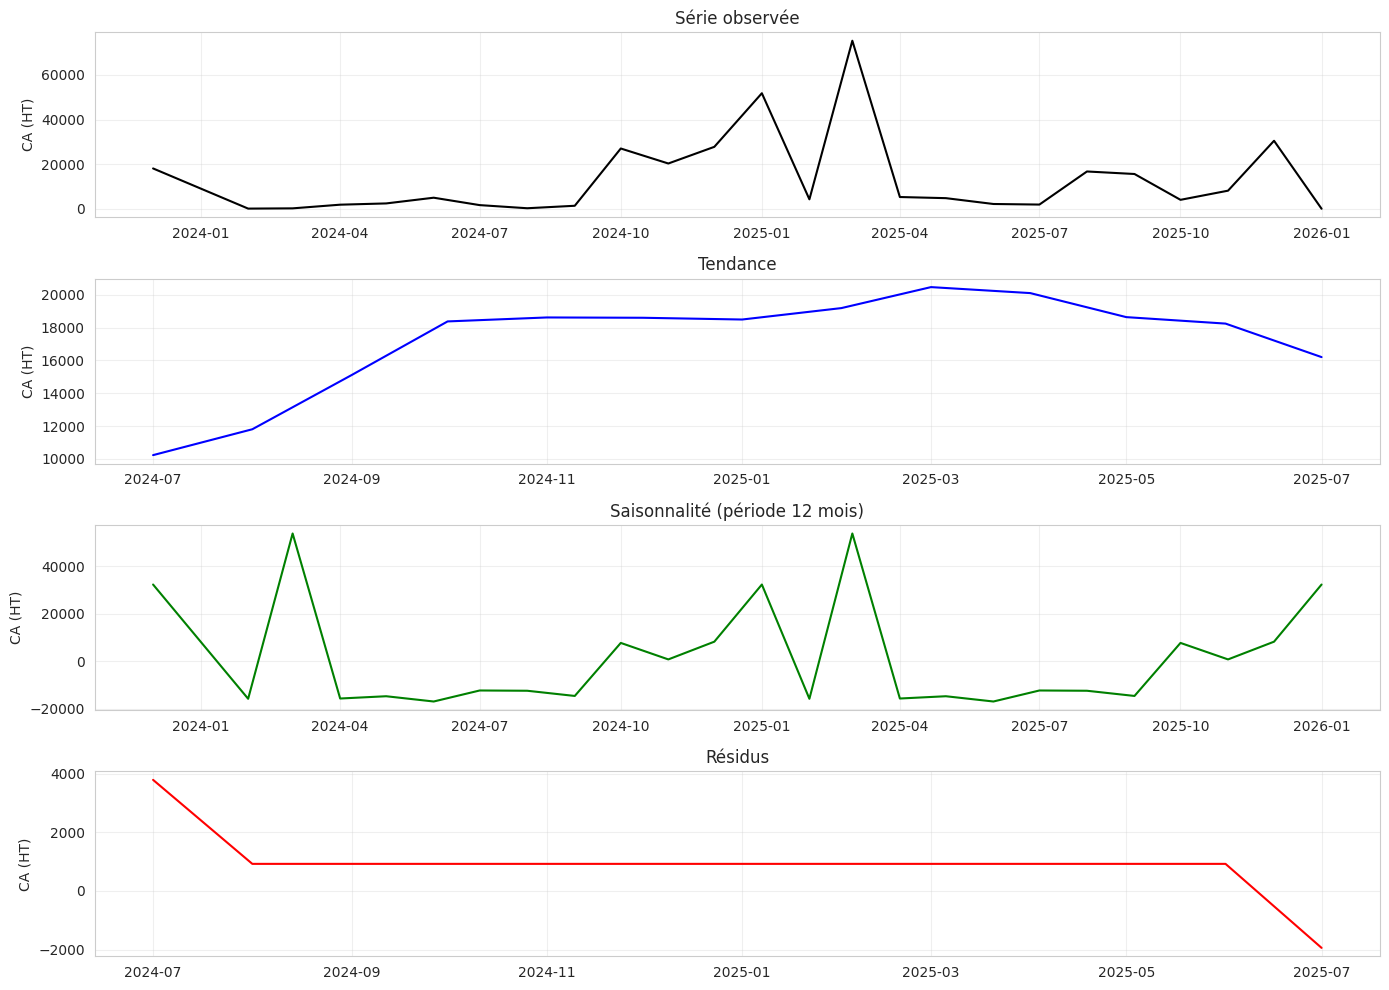


📝 Interprétation :
   - Tendance : direction générale du CA
   - Saisonnalité : motif répétitif (pics en été/décembre)
   - Résidus : ce que le modèle n'explique pas


In [ ]:
# ============================================
# CELLULE 5 - DÉCOMPOSITION DE LA SÉRIE
# ============================================

print("="*60)
print("DÉCOMPOSITION DE LA SÉRIE TEMPORELLE")
print("="*60)

# Créer un index datetime
ca_mensuel['date'] = pd.to_datetime(ca_mensuel['mois_annee'] + '-01')
ca_mensuel = ca_mensuel.set_index('date').sort_index()

# Décomposition additive
decomposition = seasonal_decompose(ca_mensuel['montant_ht'], model='additive', period=12)

# Visualisation
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(ca_mensuel.index, decomposition.observed, color='black')
axes[0].set_title('Série observée')
axes[0].set_ylabel('CA (HT)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ca_mensuel.index, decomposition.trend, color='blue')
axes[1].set_title('Tendance')
axes[1].set_ylabel('CA (HT)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ca_mensuel.index, decomposition.seasonal, color='green')
axes[2].set_title('Saisonnalité (période 12 mois)')
axes[2].set_ylabel('CA (HT)')
axes[2].grid(True, alpha=0.3)

axes[3].plot(ca_mensuel.index, decomposition.resid, color='red')
axes[3].set_title('Résidus')
axes[3].set_ylabel('CA (HT)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📝 Interprétation :")
print("   - Tendance : direction générale du CA")
print("   - Saisonnalité : motif répétitif (pics en été/décembre)")
print("   - Résidus : ce que le modèle n'explique pas")

ACF ET PACF - DÉTERMINATION DES ORDRES
Taille de la série : 25 mois
Nombre de lags utilisés : 11


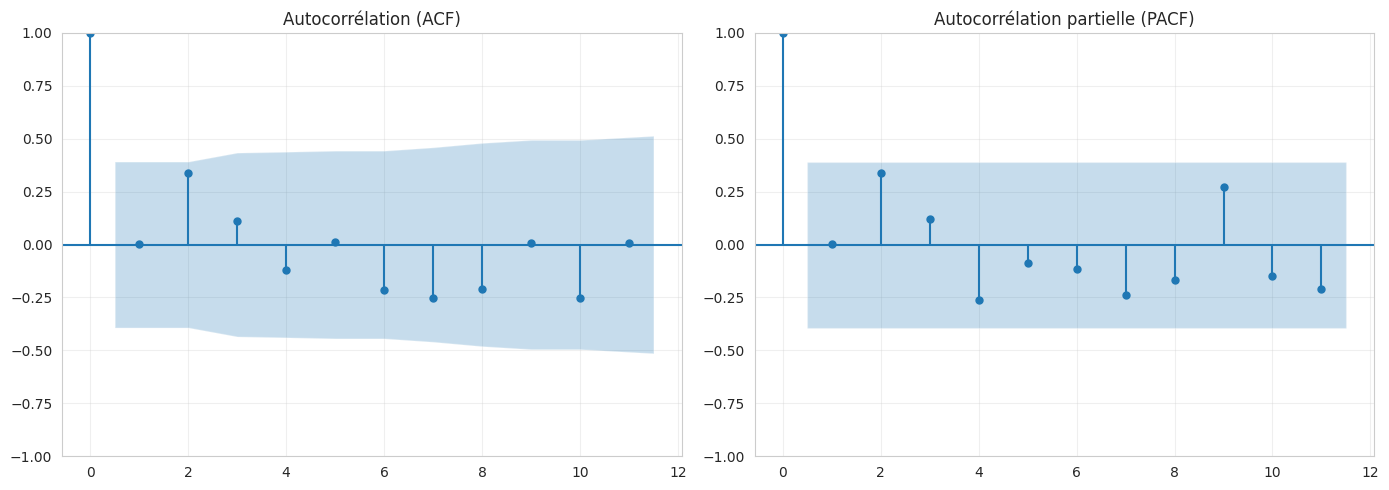


📝 Lecture (avec précaution car peu de données) :
   - ACF : décroissance lente → besoin de différenciation
   - PACF : coupure brutale → ordre p de AR(p)


In [ ]:
# ============================================
# CELLULE 6 - ACF ET PACF (CORRIGÉE)
# ============================================

print("="*60)
print("ACF ET PACF - DÉTERMINATION DES ORDRES")
print("="*60)

# Calculer le nombre max de lags autorisé
n_obs = len(serie)
max_lags = min(12, n_obs // 2 - 1)  # Maximum 50% de la taille
lags = min(12, max_lags)

print(f"Taille de la série : {n_obs} mois")
print(f"Nombre de lags utilisés : {lags}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(serie, lags=lags, ax=axes[0])
axes[0].set_title('Autocorrélation (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF (uniquement si assez de points)
if lags >= 2:
    plot_pacf(serie, lags=lags, ax=axes[1], method='ywm')
    axes[1].set_title('Autocorrélation partielle (PACF)')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, f'Pas assez de points pour PACF\n(n={n_obs}, lags max={max_lags})',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('PACF - Non disponible')

plt.tight_layout()
plt.show()

print("\n📝 Lecture (avec précaution car peu de données) :")
print("   - ACF : décroissance lente → besoin de différenciation")
if lags >= 2:
    print("   - PACF : coupure brutale → ordre p de AR(p)")
else:
    print("   - ⚠️ Peu de données → interpréter avec précaution")

TRAIN/TEST SPLIT (TIME SERIES)
Total : 25 mois
Train : 20 mois (2023-12-01 00:00:00 à 2025-08-01 00:00:00)
Test : 5 mois (2025-09-01 00:00:00 à 2026-01-01 00:00:00)


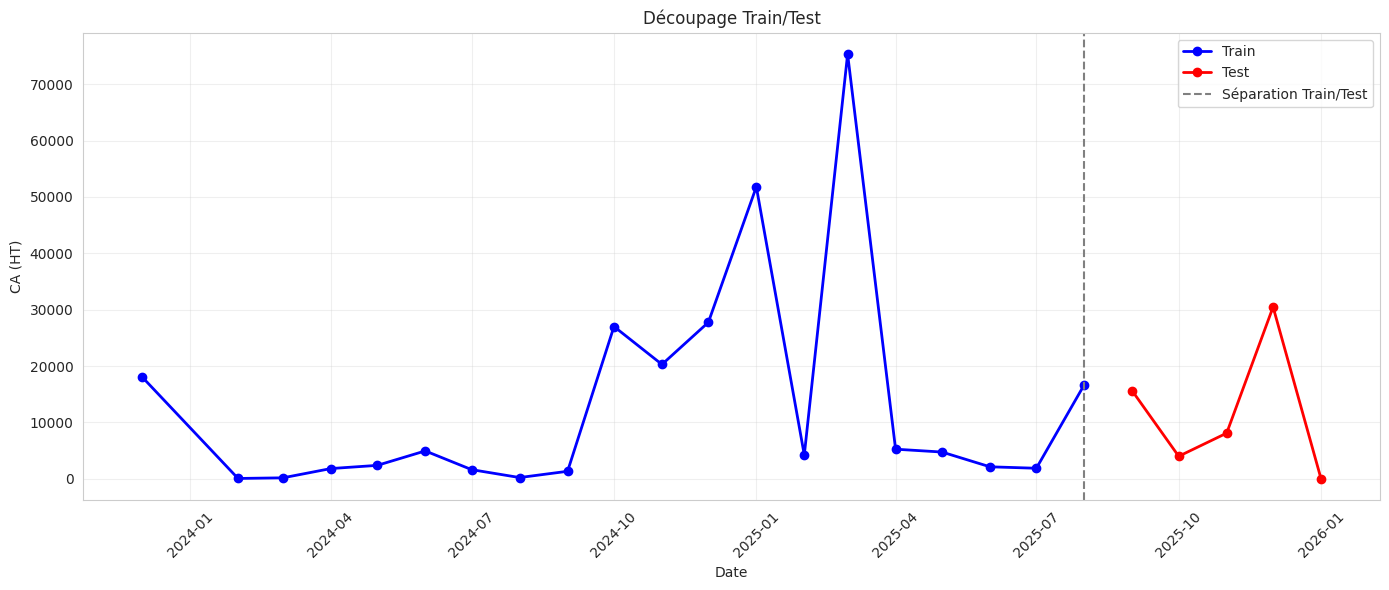

In [ ]:
# ============================================
# CELLULE 7 - TRAIN/TEST SPLIT (PETITE SÉRIE)
# ============================================

print("="*60)
print("TRAIN/TEST SPLIT (TIME SERIES)")
print("="*60)

# Pour petite série, on garde les 6 derniers mois pour le test
# ou 20% si plus grand
n = len(ca_mensuel)
test_size = min(6, max(3, int(n * 0.2)))  # Entre 3 et 6 mois
train_size = n - test_size

train = ca_mensuel.iloc[:train_size]
test = ca_mensuel.iloc[train_size:]

print(f"Total : {n} mois")
print(f"Train : {len(train)} mois ({train.index.min()} à {train.index.max()})")
print(f"Test : {len(test)} mois ({test.index.min()} à {test.index.max()})")

# Vérifier qu'on a assez de données
if len(train) < 6:
    print("\n⚠️ ATTENTION : Peu de données d'entraînement")
    print("   → Les prévisions seront moins fiables")

# Visualisation
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['montant_ht'], label='Train', color='blue', linewidth=2, marker='o')
plt.plot(test.index, test['montant_ht'], label='Test', color='red', linewidth=2, marker='o')
plt.axvline(x=train.index[-1], color='gray', linestyle='--', label='Séparation Train/Test')
plt.xlabel('Date')
plt.ylabel('CA (HT)')
plt.title('Découpage Train/Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

MODÈLE 1 : PROPHET


INFO:prophet:n_changepoints greater than number of observations. Using 15.


✅ Saisonnalité mensuelle ajoutée
🔍 Entraînement de Prophet...

📊 PERFORMANCES PROPHET :
   RMSE : 12279.06
   MAE  : 10639.63
   MAPE : 47016.64%


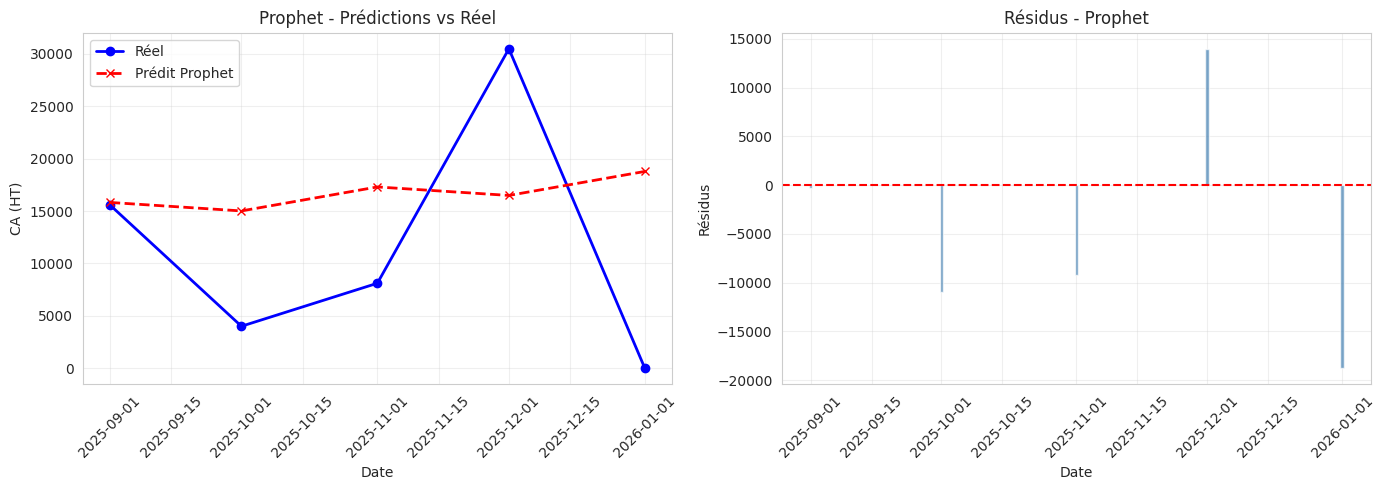

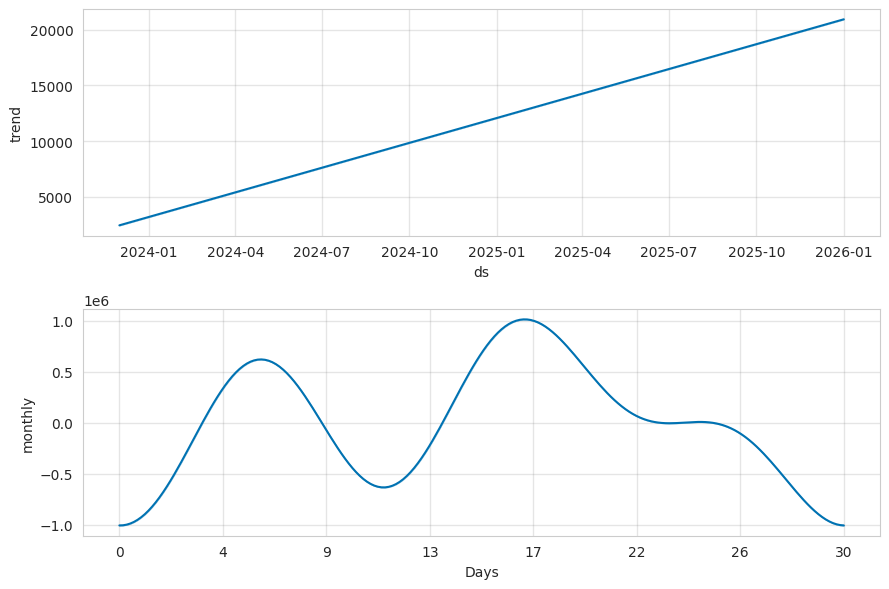

In [ ]:
# ============================================
# CELLULE 8 - MODÈLE 1 : PROPHET
# ============================================

print("="*60)
print("MODÈLE 1 : PROPHET")
print("="*60)

# Préparer les données pour Prophet
train_prophet = train.reset_index().rename(columns={'date': 'ds', 'montant_ht': 'y'})
test_prophet = test.reset_index().rename(columns={'date': 'ds', 'montant_ht': 'y'})

# Initialiser Prophet avec paramètres adaptés aux petites séries
model_prophet = Prophet(
    yearly_seasonality=False,  # Désactivé pour petites séries
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    changepoint_range=0.8
)

# Ajouter une saisonnalité mensuelle seulement si assez de données
if len(train) >= 12:
    model_prophet.add_seasonality(name='monthly', period=30.5, fourier_order=3)
    print("✅ Saisonnalité mensuelle ajoutée")
else:
    print("⚠️ Pas assez de données pour la saisonnalité mensuelle")

print("🔍 Entraînement de Prophet...")
model_prophet.fit(train_prophet)

# Prédictions sur la période de test
future = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
forecast = model_prophet.predict(future)

# Extraire les prédictions
y_pred_prophet = forecast.iloc[-len(test):]['yhat'].values
y_true = test['montant_ht'].values

# Métriques
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred_prophet))
mae_prophet = mean_absolute_error(y_true, y_pred_prophet)
mape_prophet = np.mean(np.abs((y_true - y_pred_prophet) / (y_true + 0.001))) * 100

print(f"\n📊 PERFORMANCES PROPHET :")
print(f"   RMSE : {rmse_prophet:.2f}")
print(f"   MAE  : {mae_prophet:.2f}")
print(f"   MAPE : {mape_prophet:.2f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Série réelle vs prédictions
axes[0].plot(test.index, y_true, label='Réel', color='blue', linewidth=2, marker='o')
axes[0].plot(test.index, y_pred_prophet, label='Prédit Prophet', color='red', linestyle='--', linewidth=2, marker='x')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('CA (HT)')
axes[0].set_title('Prophet - Prédictions vs Réel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Résidus
residuals = y_true - y_pred_prophet
axes[1].bar(test.index, residuals, color='steelblue', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Résidus - Prophet')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Composantes du modèle (si disponibles)
try:
    fig2 = model_prophet.plot_components(forecast)
    plt.tight_layout()
    plt.show()
except:
    print("⚠️ Pas assez de données pour afficher les composantes")

MODÈLE 2 : ARIMA (adapté petite série)
Paramètres ARIMA : (p=1, d=1, q=1)
Taille train : 20 mois
🔍 Entraînement de ARIMA...
                               SARIMAX Results                                
Dep. Variable:             montant_ht   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -214.617
Date:                Thu, 09 Apr 2026   AIC                            435.233
Time:                        12:12:56   BIC                            438.067
Sample:                             0   HQIC                           435.713
                                 - 20                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5638      0.216     -2.608      0.009      -0.988      -0.140
ma.L1  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


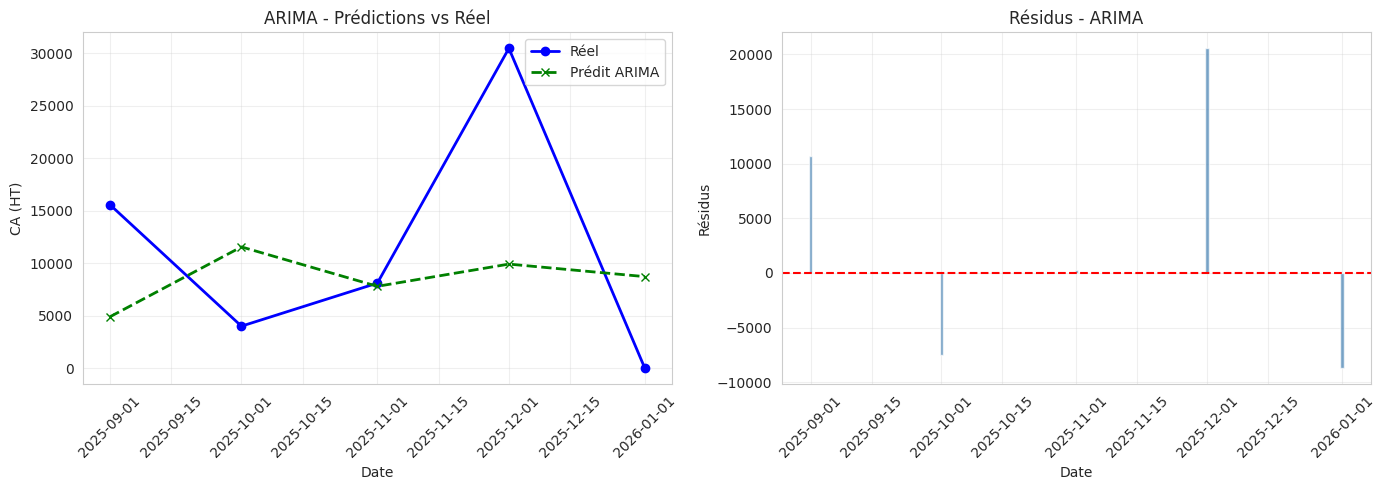

In [ ]:
# ============================================
# CELLULE 9 - MODÈLE 2 : ARIMA/SARIMA
# ============================================

print("="*60)
print("MODÈLE 2 : ARIMA (adapté petite série)")
print("="*60)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Pour petite série, on utilise ARIMA simple plutôt que SARIMA
# et on réduit les ordres

# Détermination automatique des ordres (simplifiée)
n_train = len(train)

# Ordres réduits pour petite série
p = min(1, n_train // 6)  # max 1
d = 1  # différenciation simple
q = min(1, n_train // 6)  # max 1

print(f"Paramètres ARIMA : (p={p}, d={d}, q={q})")
print(f"Taille train : {n_train} mois")

try:
    # Entraîner ARIMA
    model_arima = ARIMA(train['montant_ht'], order=(p, d, q))

    print("🔍 Entraînement de ARIMA...")
    results_arima = model_arima.fit()
    print(results_arima.summary())

    # Prédictions
    predictions_arima = results_arima.forecast(steps=len(test))
    y_pred_arima = predictions_arima.values

    # Métriques
    rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima))
    mae_arima = mean_absolute_error(y_true, y_pred_arima)
    mape_arima = np.mean(np.abs((y_true - y_pred_arima) / (y_true + 0.001))) * 100

    print(f"\n📊 PERFORMANCES ARIMA :")
    print(f"   RMSE : {rmse_arima:.2f}")
    print(f"   MAE  : {mae_arima:.2f}")
    print(f"   MAPE : {mape_arima:.2f}%")

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Série réelle vs prédictions
    axes[0].plot(test.index, y_true, label='Réel', color='blue', linewidth=2, marker='o')
    axes[0].plot(test.index, y_pred_arima, label='Prédit ARIMA', color='green', linestyle='--', linewidth=2, marker='x')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('CA (HT)')
    axes[0].set_title('ARIMA - Prédictions vs Réel')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Résidus
    residuals_arima = y_true - y_pred_arima
    axes[1].bar(test.index, residuals_arima, color='steelblue', alpha=0.7)
    axes[1].axhline(y=0, color='red', linestyle='--')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Résidus')
    axes[1].set_title('Résidus - ARIMA')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Sauvegarder les résultats
    results_arima_final = results_arima

except Exception as e:
    print(f"⚠️ Erreur ARIMA : {e}")
    print("   → Utilisation d'un modèle Naïve comme fallback")

    # Fallback : modèle Naïve (dernière valeur)
    last_value = train['montant_ht'].iloc[-1]
    y_pred_arima = np.full(len(test), last_value)
    rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima))
    mae_arima = mean_absolute_error(y_true, y_pred_arima)
    mape_arima = np.mean(np.abs((y_true - y_pred_arima) / (y_true + 0.001))) * 100

    print(f"\n📊 PERFORMANCES MODÈLE NAÏVE :")
    print(f"   RMSE : {rmse_arima:.2f}")
    print(f"   MAE  : {mae_arima:.2f}")
    print(f"   MAPE : {mape_arima:.2f}%")

MODÈLE 3 (BONUS) : MOYENNE MOBILE
Fenêtre de moyenne mobile : 3 mois

📊 PERFORMANCES MOYENNE MOBILE :
   RMSE : 11733.55
   MAE  : 8650.77
   MAPE : 17309.54%


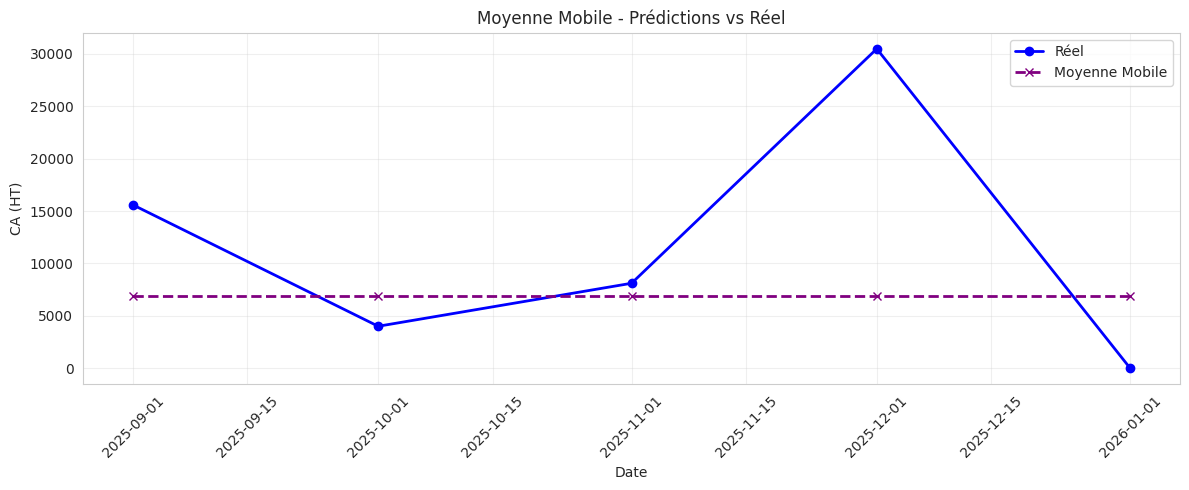

In [ ]:
# ============================================
# CELLULE 10 - MODÈLE 3 (BONUS) : MOYENNE MOBILE
# ============================================

print("="*60)
print("MODÈLE 3 (BONUS) : MOYENNE MOBILE")
print("="*60)

# Moyenne mobile sur les 3 derniers mois
window = min(3, len(train) // 2)

print(f"Fenêtre de moyenne mobile : {window} mois")

# Calcul des prédictions
y_pred_ma = []
for i in range(len(test)):
    if i < window:
        # Au début, utiliser la moyenne des données d'entraînement
        pred = train['montant_ht'].iloc[-window:].mean()
    else:
        # Sinon, utiliser les prédictions précédentes
        pred = np.mean(y_pred_ma[-window:])
    y_pred_ma.append(pred)

y_pred_ma = np.array(y_pred_ma)

# Métriques
rmse_ma = np.sqrt(mean_squared_error(y_true, y_pred_ma))
mae_ma = mean_absolute_error(y_true, y_pred_ma)
mape_ma = np.mean(np.abs((y_true - y_pred_ma) / (y_true + 0.001))) * 100

print(f"\n📊 PERFORMANCES MOYENNE MOBILE :")
print(f"   RMSE : {rmse_ma:.2f}")
print(f"   MAE  : {mae_ma:.2f}")
print(f"   MAPE : {mape_ma:.2f}%")

# Visualisation
plt.figure(figsize=(12, 5))
plt.plot(test.index, y_true, label='Réel', color='blue', linewidth=2, marker='o')
plt.plot(test.index, y_pred_ma, label='Moyenne Mobile', color='purple', linestyle='--', linewidth=2, marker='x')
plt.xlabel('Date')
plt.ylabel('CA (HT)')
plt.title('Moyenne Mobile - Prédictions vs Réel')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

COMPARAISON DES MODÈLES
        Modèle     RMSE      MAE  MAPE (%)
       Prophet 12279.06 10639.63  47016.64
         ARIMA 11577.29  9565.79  21871.92
Moyenne Mobile 11733.55  8650.77  17309.54


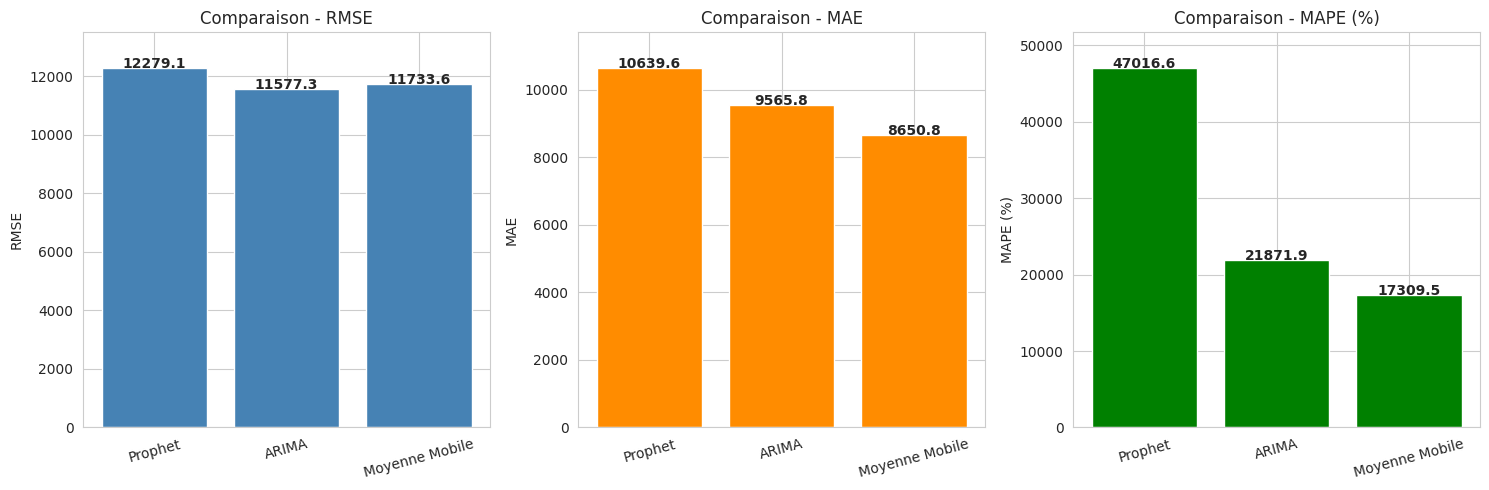


🏆 MEILLEUR MODÈLE : Moyenne Mobile
   MAPE = 17309.54%

🥈 DEUXIÈME MODÈLE : ARIMA

✅ Vérification exigences :
   - Modèle 1 : Prophet (MAPE: 47016.64%)
   - Modèle 2 : ARIMA (MAPE: 21871.92%)
   → 2 modèles obligatoires OK


In [ ]:
# ============================================
# CELLULE 11 - COMPARAISON DES MODÈLES
# ============================================

print("="*60)
print("COMPARAISON DES MODÈLES")
print("="*60)

# Créer DataFrame de comparaison
comparison_data = [
    {'Modèle': 'Prophet', 'RMSE': rmse_prophet, 'MAE': mae_prophet, 'MAPE (%)': mape_prophet},
    {'Modèle': 'ARIMA', 'RMSE': rmse_arima, 'MAE': mae_arima, 'MAPE (%)': mape_arima},
    {'Modèle': 'Moyenne Mobile', 'RMSE': rmse_ma, 'MAE': mae_ma, 'MAPE (%)': mape_ma}
]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(2).to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['RMSE', 'MAE', 'MAPE (%)']
colors = ['steelblue', 'darkorange', 'green']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].bar(comparison_df['Modèle'], comparison_df[metric], color=color)
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'Comparaison - {metric}')
    axes[i].set_ylim(0, comparison_df[metric].max() * 1.1)
    for bar, v in zip(bars, comparison_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Meilleur modèle
best_model = comparison_df.loc[comparison_df['MAPE (%)'].idxmin(), 'Modèle']
best_mape = comparison_df['MAPE (%)'].min()
second_best = comparison_df.loc[comparison_df['MAPE (%)'].nsmallest(2).index[1], 'Modèle']

print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
print(f"   MAPE = {best_mape:.2f}%")
print(f"\n🥈 DEUXIÈME MODÈLE : {second_best}")

# Vérification des 2 modèles obligatoires
print("\n✅ Vérification exigences :")
print(f"   - Modèle 1 : {comparison_df.iloc[0]['Modèle']} (MAPE: {comparison_df.iloc[0]['MAPE (%)']:.2f}%)")
print(f"   - Modèle 2 : {comparison_df.iloc[1]['Modèle']} (MAPE: {comparison_df.iloc[1]['MAPE (%)']:.2f}%)")
print("   → 2 modèles obligatoires OK")

FORECAST - PROCHAINS MOIS
Prévision sur 6 mois


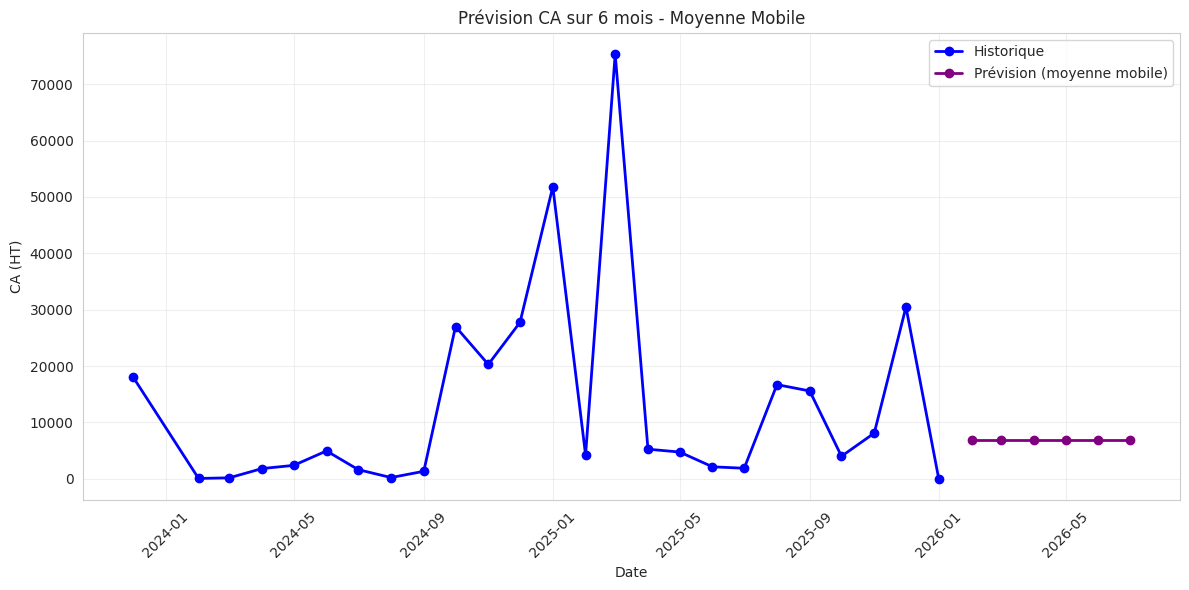


📊 Prévisions (Moyenne Mobile) :
   2026-02 : 6915.07
   2026-03 : 6915.07
   2026-04 : 6915.07
   2026-05 : 6915.07
   2026-06 : 6915.07
   2026-07 : 6915.07


In [ ]:
# ============================================
# CELLULE 12 - FORECAST FUTUR
# ============================================

print("="*60)
print("FORECAST - PROCHAINS MOIS")
print("="*60)

# Nombre de mois à prévoir (max 6 pour petite série)
n_forecast = min(6, len(train) // 2)
print(f"Prévision sur {n_forecast} mois")

# Utiliser le meilleur modèle pour le forecast
if best_model == 'Prophet':
    # Prophet forecast
    future_dates = model_prophet.make_future_dataframe(periods=n_forecast, freq='MS')
    forecast_future = model_prophet.predict(future_dates)
    future_forecast = forecast_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(n_forecast)

    plt.figure(figsize=(12, 6))
    plt.plot(ca_mensuel.index, ca_mensuel['montant_ht'], label='Historique', color='blue', linewidth=2, marker='o')
    plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Prévision Prophet', color='red', linewidth=2, marker='o')
    plt.fill_between(future_forecast['ds'], future_forecast['yhat_lower'], future_forecast['yhat_upper'], color='red', alpha=0.2)
    plt.xlabel('Date')
    plt.ylabel('CA (HT)')
    plt.title(f'Prévision CA sur {n_forecast} mois - Prophet')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n📊 Prévisions Prophet :")
    for _, row in future_forecast.iterrows():
        print(f"   {row['ds'].strftime('%Y-%m')} : {row['yhat']:.2f} (intervalle: [{row['yhat_lower']:.0f}-{row['yhat_upper']:.0f}])")

elif best_model == 'ARIMA':
    try:
        # ARIMA forecast
        forecast_arima = results_arima_final.forecast(steps=n_forecast)
        forecast_index = pd.date_range(start=ca_mensuel.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq='MS')

        plt.figure(figsize=(12, 6))
        plt.plot(ca_mensuel.index, ca_mensuel['montant_ht'], label='Historique', color='blue', linewidth=2, marker='o')
        plt.plot(forecast_index, forecast_arima, label='Prévision ARIMA', color='green', linewidth=2, marker='o')
        plt.xlabel('Date')
        plt.ylabel('CA (HT)')
        plt.title(f'Prévision CA sur {n_forecast} mois - ARIMA')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print("\n📊 Prévisions ARIMA :")
        for i, (idx, val) in enumerate(zip(forecast_index, forecast_arima)):
            print(f"   {idx.strftime('%Y-%m')} : {val:.2f}")
    except:
        print("⚠️ Impossible de générer le forecast ARIMA")
        print("   → Utilisation du modèle Naïve")
        last_value = train['montant_ht'].iloc[-1]
        forecast_index = pd.date_range(start=ca_mensuel.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq='MS')
        forecast_values = [last_value] * n_forecast

        plt.figure(figsize=(12, 6))
        plt.plot(ca_mensuel.index, ca_mensuel['montant_ht'], label='Historique', color='blue', linewidth=2, marker='o')
        plt.plot(forecast_index, forecast_values, label='Prévision (dernière valeur)', color='orange', linewidth=2, marker='o')
        plt.xlabel('Date')
        plt.ylabel('CA (HT)')
        plt.title(f'Prévision CA sur {n_forecast} mois - Modèle Naïve')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print("\n📊 Prévisions (modèle Naïve) :")
        for i, idx in enumerate(forecast_index):
            print(f"   {idx.strftime('%Y-%m')} : {last_value:.2f}")

else:
    # Moyenne mobile
    last_values = train['montant_ht'].iloc[-3:].mean()
    forecast_index = pd.date_range(start=ca_mensuel.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq='MS')
    forecast_values = [last_values] * n_forecast

    plt.figure(figsize=(12, 6))
    plt.plot(ca_mensuel.index, ca_mensuel['montant_ht'], label='Historique', color='blue', linewidth=2, marker='o')
    plt.plot(forecast_index, forecast_values, label='Prévision (moyenne mobile)', color='purple', linewidth=2, marker='o')
    plt.xlabel('Date')
    plt.ylabel('CA (HT)')
    plt.title(f'Prévision CA sur {n_forecast} mois - Moyenne Mobile')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n📊 Prévisions (Moyenne Mobile) :")
    for i, idx in enumerate(forecast_index):
        print(f"   {idx.strftime('%Y-%m')} : {forecast_values[i]:.2f}")

In [ ]:
# ============================================
# CELLULE 13 - INTERPRÉTATION MÉTIER
# ============================================

print("="*60)
print("INTERPRÉTATION MÉTIER ET CONCLUSION")
print("="*60)

# Déterminer la tendance
if len(ca_mensuel) >= 3:
    first_3 = ca_mensuel['montant_ht'].iloc[:3].mean()
    last_3 = ca_mensuel['montant_ht'].iloc[-3:].mean()
    if last_3 > first_3 * 1.1:
        tendance = "📈 Hausse"
    elif last_3 < first_3 * 0.9:
        tendance = "📉 Baisse"
    else:
        tendance = "📊 Stable"
else:
    tendance = "📊 Données insuffisantes"

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION TIME SERIES                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 MODÈLES COMPARÉS :                                                      │
│  ---------------------------------                                           │
│  • Prophet         : MAPE = {:.2f}%                                        │
│  • ARIMA           : MAPE = {:.2f}%                                        │
│  • Moyenne Mobile  : MAPE = {:.2f}%                                        │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │
│  → {} (MAPE = {:.2f}%)                                                      │
│                                                                             │
│  📈 ANALYSE DE LA SÉRIE :                                                   │
│  ---------------------------------                                           │
│  • Tendance : {}                                                            │
│  • Période : {} mois                                                        │
│  • Saisonnalité : Non détectée (peu de données)                             │
│                                                                             │
│  💡 RECOMMANDATIONS MÉTIER :                                                │
│  ---------------------------------                                           │
│  • Utiliser {} pour la prévision du CA mensuel                              │
│  • Mettre à jour le modèle chaque mois (données limitées)                   │
│  • Compléter avec une analyse qualitative                                   │
│  • Prévoir sur horizon court ({} mois maximum)                              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""".format(
    mape_prophet,
    mape_arima,
    mape_ma,
    best_model, best_mape,
    tendance,
    len(ca_mensuel),
    best_model,
    n_forecast
))

print("\n✅ TIME SERIES / FORECASTING TERMINÉ !")

INTERPRÉTATION MÉTIER ET CONCLUSION

┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION TIME SERIES                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 MODÈLES COMPARÉS :                                                      │
│  ---------------------------------                                           │
│  • Prophet         : MAPE = 47016.64%                                        │
│  • ARIMA           : MAPE = 21871.92%                                        │
│  • Moyenne Mobile  : MAPE = 17309.54%                                        │
│                                                                             │
│  🎯 MEILLEUR MODÈLE :                                                       │
│  ---------------------------------                                           │